# Power Usage Prediction Models
Predict hourly power usage for 10 days (BF-9 to BF) across all load areas

## Rolling Window Strategy:
- 2016-2019 → Predict 2020
- 2017-2020 → Predict 2021
- 2018-2021 → Predict 2022
- 2019-2022 → Predict 2023
- 2020-2023 → Predict 2024

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Load Preprocessed Data

In [ ]:
# Load preprocessed data
df = pd.read_csv('dataset/preprocessed/preprocessed_black_friday_data.csv')

# Convert datetime
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])
df['black_friday'] = pd.to_datetime(df['black_friday'])

print(f"Total data loaded: {len(df):,} rows")
print(f"\nYears available: {sorted(df['year'].unique())}")
print(f"Load areas: {len(df['load_area'].unique())}")
print(df.head())

## Feature Engineering for Hourly Prediction

In [3]:
# Add time features
df['hour'] = df['datetime_beginning_ept'].dt.hour
df['day_of_week'] = df['datetime_beginning_ept'].dt.dayofweek
df['month'] = df['datetime_beginning_ept'].dt.month
df['day'] = df['datetime_beginning_ept'].dt.day

# Calculate days from Black Friday
df['days_from_bf'] = (df['datetime_beginning_ept'] - df['black_friday']).dt.days

print("Features added:")
print(df[['datetime_beginning_ept', 'load_area', 'mw', 'year', 'days_from_bf', 'hour']].head(10))

Features added:
  datetime_beginning_ept load_area        mw  year  days_from_bf  hour
0             2016-11-01        AE   849.077  2016           -24     0
1             2016-11-01        BC  2624.072  2016           -24     0
2             2016-11-01     DPLCO  1505.922  2016           -24     0
3             2016-11-01    EASTON    20.925  2016           -24     0
4             2016-11-01        JC  1886.445  2016           -24     0
5             2016-11-01        ME  1430.081  2016           -24     0
6             2016-11-01        PE  3303.442  2016           -24     0
7             2016-11-01     PEPCO  2161.229  2016           -24     0
8             2016-11-01     SMECO   270.839  2016           -24     0
9             2016-11-01      PLCO  3659.217  2016           -24     0


## Filter Data for Prediction Period (BF-9 to BF)

In [4]:
# Filter data: Only keep BF-9 to BF (10 days)
prediction_period_df = df[(df['days_from_bf'] >= -9) & (df['days_from_bf'] <= 0)].copy()

print(f"Data for prediction period (BF-9 to BF): {len(prediction_period_df):,} rows")
print(f"\nData count by year:")
print(prediction_period_df.groupby('year').size())
print(f"\nDays from BF range: {prediction_period_df['days_from_bf'].min()} to {prediction_period_df['days_from_bf'].max()}")
print(f"\nUnique load areas: {prediction_period_df['load_area'].nunique()}")

Data for prediction period (BF-9 to BF): 63,840 rows

Data count by year:
year
2016    6720
2017    6960
2018    6960
2019    7200
2020    7200
2021    7200
2022    7200
2023    7200
2024    7200
dtype: int64

Days from BF range: -9 to 0

Unique load areas: 31


## Model: Simple Baseline - Rolling Window Historical Average

In [5]:
# Define rolling windows
rolling_windows = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

print("Rolling windows configured:")
for idx, window in enumerate(rolling_windows, 1):
    print(f"{idx}. Train: {window['train_years']} → Test: {window['test_year']}")

Rolling windows configured:
1. Train: [2016, 2017, 2018, 2019] → Test: 2020
2. Train: [2017, 2018, 2019, 2020] → Test: 2021
3. Train: [2018, 2019, 2020, 2021] → Test: 2022
4. Train: [2019, 2020, 2021, 2022] → Test: 2023
5. Train: [2020, 2021, 2022, 2023] → Test: 2024


In [6]:
# Store all results
all_results = []
all_predictions = []

# Process each rolling window
for window_idx, window in enumerate(rolling_windows, 1):
    train_years = window['train_years']
    test_year = window['test_year']
    
    print(f"\n{'='*80}")
    print(f"Window {window_idx}: Training on {train_years} → Predicting {test_year}")
    print(f"{'='*80}")
    
    # Split data
    train_df = prediction_period_df[prediction_period_df['year'].isin(train_years)].copy()
    test_df = prediction_period_df[prediction_period_df['year'] == test_year].copy()
    
    print(f"Training data: {len(train_df):,} rows")
    print(f"Test data: {len(test_df):,} rows")
    
    if len(test_df) == 0:
        print(f"No test data for {test_year}, skipping...")
        continue
    
    # Calculate baseline: Average by (load_area, days_from_bf, hour)
    baseline_avg = train_df.groupby(['load_area', 'days_from_bf', 'hour'])['mw'].mean().reset_index()
    baseline_avg.rename(columns={'mw': 'predicted_mw'}, inplace=True)
    
    print(f"Baseline patterns: {len(baseline_avg):,} unique combinations")
    
    # Make predictions
    test_with_predictions = test_df.merge(
        baseline_avg,
        on=['load_area', 'days_from_bf', 'hour'],
        how='left'
    )
    
    # Handle missing predictions
    missing_predictions = test_with_predictions['predicted_mw'].isna().sum()
    if missing_predictions > 0:
        print(f"Missing predictions: {missing_predictions}")
        # Fill with load_area average as fallback
        load_area_avg = train_df.groupby('load_area')['mw'].mean().reset_index()
        load_area_avg.rename(columns={'mw': 'fallback_mw'}, inplace=True)
        test_with_predictions = test_with_predictions.merge(load_area_avg, on='load_area', how='left')
        test_with_predictions['predicted_mw'].fillna(test_with_predictions['fallback_mw'], inplace=True)
        print(f"Filled with load_area average")
    
    # Calculate metrics by load area
    for area in sorted(test_with_predictions['load_area'].unique()):
        area_data = test_with_predictions[test_with_predictions['load_area'] == area]
        
        actual = area_data['mw'].values
        predicted = area_data['predicted_mw'].values
        
        mse = mean_squared_error(actual, predicted)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actual, predicted)
        mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100  # avoid division by zero
        
        all_results.append({
            'test_year': test_year,
            'train_years': '-'.join(map(str, train_years)),
            'load_area': area,
            'n_predictions': len(area_data),
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'avg_actual': actual.mean(),
            'avg_predicted': predicted.mean()
        })
    
    # Store predictions
    test_with_predictions['test_year'] = test_year
    test_with_predictions['train_years'] = '-'.join(map(str, train_years))
    all_predictions.append(test_with_predictions)
    
    # Overall metrics for this window
    overall_mse = mean_squared_error(test_with_predictions['mw'], test_with_predictions['predicted_mw'])
    overall_rmse = np.sqrt(overall_mse)
    overall_mae = mean_absolute_error(test_with_predictions['mw'], test_with_predictions['predicted_mw'])
    
    print(f"\nOverall performance for {test_year}:")
    print(f"  MSE:  {overall_mse:,.2f}")
    print(f"  RMSE: {overall_rmse:,.2f}")
    print(f"  MAE:  {overall_mae:,.2f}")

# Combine all results
results_df = pd.DataFrame(all_results)
all_predictions_df = pd.concat(all_predictions, ignore_index=True)

print(f"\n{'='*80}")
print(f"Total results collected: {len(results_df)} (area-year combinations)")
print(f"Total predictions: {len(all_predictions_df):,} hourly predictions")
print(f"{'='*80}")


Window 1: Training on [2016, 2017, 2018, 2019] → Predicting 2020
Training data: 27,840 rows
Test data: 7,200 rows
Baseline patterns: 7,440 unique combinations

Overall performance for 2020:
  MSE:  1,862,519.83
  RMSE: 1,364.74
  MAE:  451.92

Window 2: Training on [2017, 2018, 2019, 2020] → Predicting 2021
Training data: 28,320 rows
Test data: 7,200 rows
Baseline patterns: 7,200 unique combinations

Overall performance for 2021:
  MSE:  1,233,628.45
  RMSE: 1,110.69
  MAE:  356.55

Window 3: Training on [2018, 2019, 2020, 2021] → Predicting 2022
Training data: 28,560 rows
Test data: 7,200 rows
Baseline patterns: 7,200 unique combinations

Overall performance for 2022:
  MSE:  2,611,790.47
  RMSE: 1,616.10
  MAE:  491.20

Window 4: Training on [2019, 2020, 2021, 2022] → Predicting 2023
Training data: 28,800 rows
Test data: 7,200 rows
Baseline patterns: 7,200 unique combinations

Overall performance for 2023:
  MSE:  870,757.32
  RMSE: 933.14
  MAE:  311.67

Window 5: Training on [2020

## Results Summary by Year

In [7]:
# Summary by test year
print("\n=== MSE Summary by Test Year ===")
year_summary = results_df.groupby('test_year')['mse'].agg(['mean', 'median', 'min', 'max', 'std'])
print(year_summary)

print("\n=== Best and Worst Performing Areas by Year ===")
for year in sorted(results_df['test_year'].unique()):
    year_data = results_df[results_df['test_year'] == year].sort_values('mse')
    best = year_data.iloc[0]
    worst = year_data.iloc[-1]
    print(f"\n{year}:")
    print(f"  Best:  {best['load_area']} (MSE: {best['mse']:,.2f})")
    print(f"  Worst: {worst['load_area']} (MSE: {worst['mse']:,.2f})")


=== MSE Summary by Test Year ===
                   mean        median        min           max           std
test_year                                                                   
2020       1.862520e+06  35006.811216  23.151410  5.138216e+07  9.356643e+06
2021       1.233628e+06  35503.639960  18.256621  3.197622e+07  5.834247e+06
2022       2.611790e+06  46750.597278  18.993300  7.027752e+07  1.281117e+07
2023       8.707573e+05  35737.522925  13.023261  2.283390e+07  4.156498e+06
2024       1.364910e+06  36255.108463  13.449387  3.571722e+07  6.509477e+06

=== Best and Worst Performing Areas by Year ===

2020:
  Best:  EASTON (MSE: 23.15)
  Worst: RTO (MSE: 51,382,155.02)

2021:
  Best:  EASTON (MSE: 18.26)
  Worst: RTO (MSE: 31,976,222.82)

2022:
  Best:  EASTON (MSE: 18.99)
  Worst: RTO (MSE: 70,277,515.16)

2023:
  Best:  EASTON (MSE: 13.02)
  Worst: RTO (MSE: 22,833,903.00)

2024:
  Best:  EASTON (MSE: 13.45)
  Worst: RTO (MSE: 35,717,224.86)


## Results by Load Area (Averaged Across Years)

In [8]:
# Average MSE by load area across all test years
area_summary = results_df.groupby('load_area').agg({
    'mse': ['mean', 'std'],
    'rmse': 'mean',
    'mae': 'mean',
    'mape': 'mean',
    'n_predictions': 'sum'
}).reset_index()

area_summary.columns = ['load_area', 'avg_mse', 'std_mse', 'avg_rmse', 'avg_mae', 'avg_mape', 'total_predictions']
area_summary = area_summary.sort_values('avg_mse')

print("\n=== Average Performance by Load Area (Across All Test Years) ===")
print(area_summary.to_string(index=False))


=== Average Performance by Load Area (Across All Test Years) ===
load_area      avg_mse      std_mse    avg_rmse     avg_mae  avg_mape  total_predictions
   EASTON 1.737480e+01 4.216371e+00    4.143723    3.341727 12.678153               1200
     VMEU 3.121909e+01 9.100185e+00    5.543980    4.038407  5.740212               1200
     RECO 5.660768e+01 2.643856e+01    7.381530    6.204701  4.409624               1200
     OVEC 1.153018e+02 3.882439e+01   10.610008    8.565347 24.860833               1200
      UGI 1.420771e+02 5.587922e+01   11.741096    9.618264  8.181776               1200
    PAPWR 2.740642e+03 1.821861e+03   50.388368   42.561339  8.172976               1200
    SMECO 4.851816e+03 1.122929e+03   69.260878   55.476116 14.812752               1200
     AECO 5.947561e+03 6.665235e+02   77.020900   61.356476  7.041240               1200
      DUQ 9.887087e+03 6.464391e+03   95.302275   80.935486  5.814348               1200
   AEPKPT 1.143464e+04 4.145732e+03  105.442

## Save Results

In [ ]:
# Save detailed results (area x year)
results_df.to_csv('dataset/preprocessed/baseline_rolling_mse_by_area_year.csv', index=False)
print("Detailed results saved to: dataset/preprocessed/baseline_rolling_mse_by_area_year.csv")

# Save area summary
area_summary.to_csv('dataset/preprocessed/baseline_rolling_mse_by_area_summary.csv', index=False)
print("Area summary saved to: dataset/preprocessed/baseline_rolling_mse_by_area_summary.csv")

# Save all predictions
predictions_output = all_predictions_df[[
    'test_year', 'train_years', 'datetime_beginning_ept', 'load_area', 
    'days_from_bf', 'hour', 'mw', 'predicted_mw'
]].copy()
predictions_output['model'] = 'baseline_rolling_avg'
predictions_output['error'] = predictions_output['mw'] - predictions_output['predicted_mw']
predictions_output['abs_error'] = np.abs(predictions_output['error'])
predictions_output['pct_error'] = (predictions_output['error'] / (predictions_output['mw'] + 1e-10)) * 100

predictions_output.to_csv('dataset/preprocessed/baseline_rolling_predictions_all_years.csv', index=False)
print("All predictions saved to: dataset/preprocessed/baseline_rolling_predictions_all_years.csv")

## Visualizations

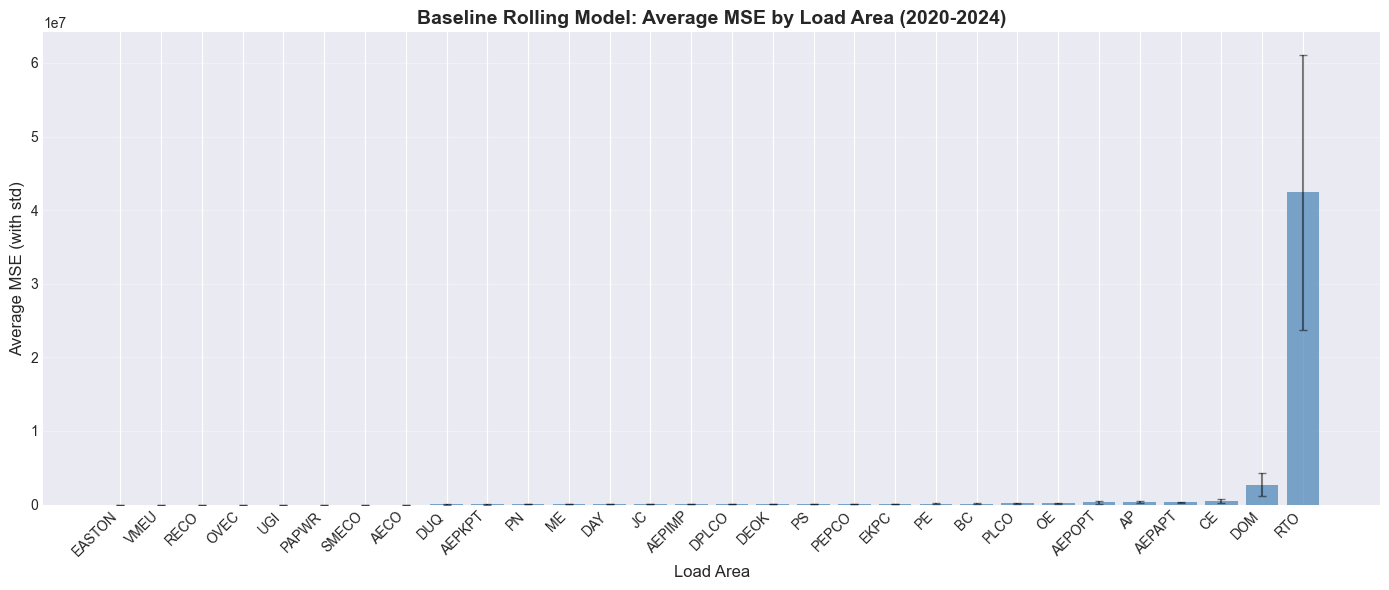

In [10]:
# Plot 1: MSE by load area (averaged across years)
plt.figure(figsize=(14, 6))
plt.bar(range(len(area_summary)), area_summary['avg_mse'], color='steelblue', alpha=0.7)
plt.errorbar(range(len(area_summary)), area_summary['avg_mse'], yerr=area_summary['std_mse'], 
             fmt='none', color='black', alpha=0.5, capsize=3)
plt.xticks(range(len(area_summary)), area_summary['load_area'], rotation=45, ha='right')
plt.xlabel('Load Area', fontsize=12)
plt.ylabel('Average MSE (with std)', fontsize=12)
plt.title('Baseline Rolling Model: Average MSE by Load Area (2020-2024)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

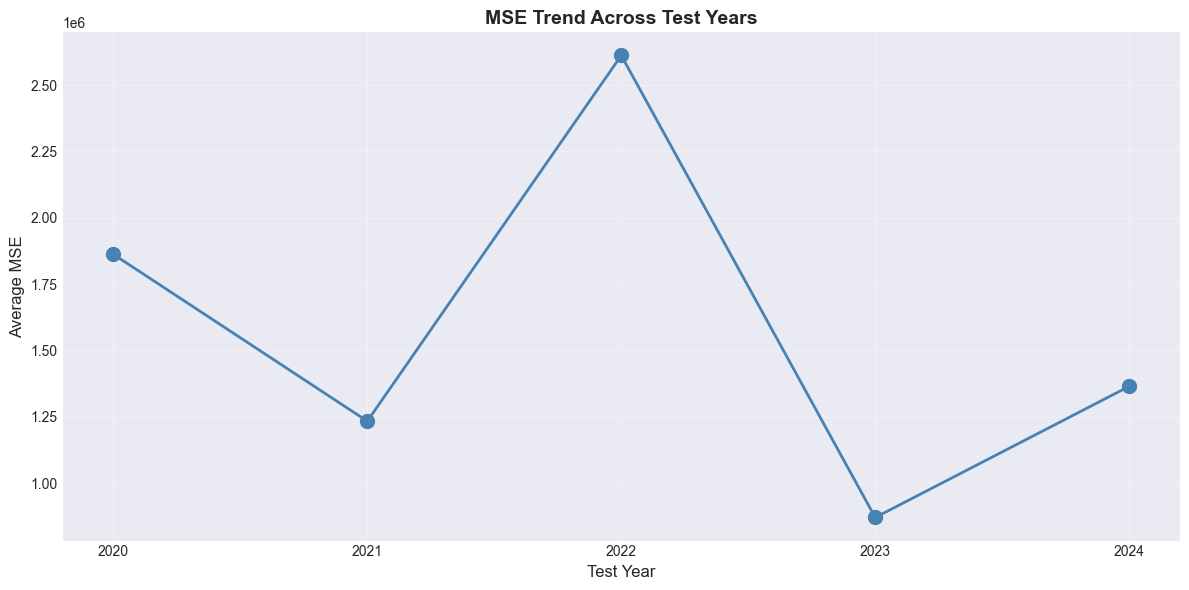

In [11]:
# Plot 2: MSE trends by year
plt.figure(figsize=(12, 6))
year_mse = results_df.groupby('test_year')['mse'].mean().reset_index()
plt.plot(year_mse['test_year'], year_mse['mse'], marker='o', linewidth=2, markersize=10, color='steelblue')
plt.xlabel('Test Year', fontsize=12)
plt.ylabel('Average MSE', fontsize=12)
plt.title('MSE Trend Across Test Years', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(year_mse['test_year'])
plt.tight_layout()
plt.show()

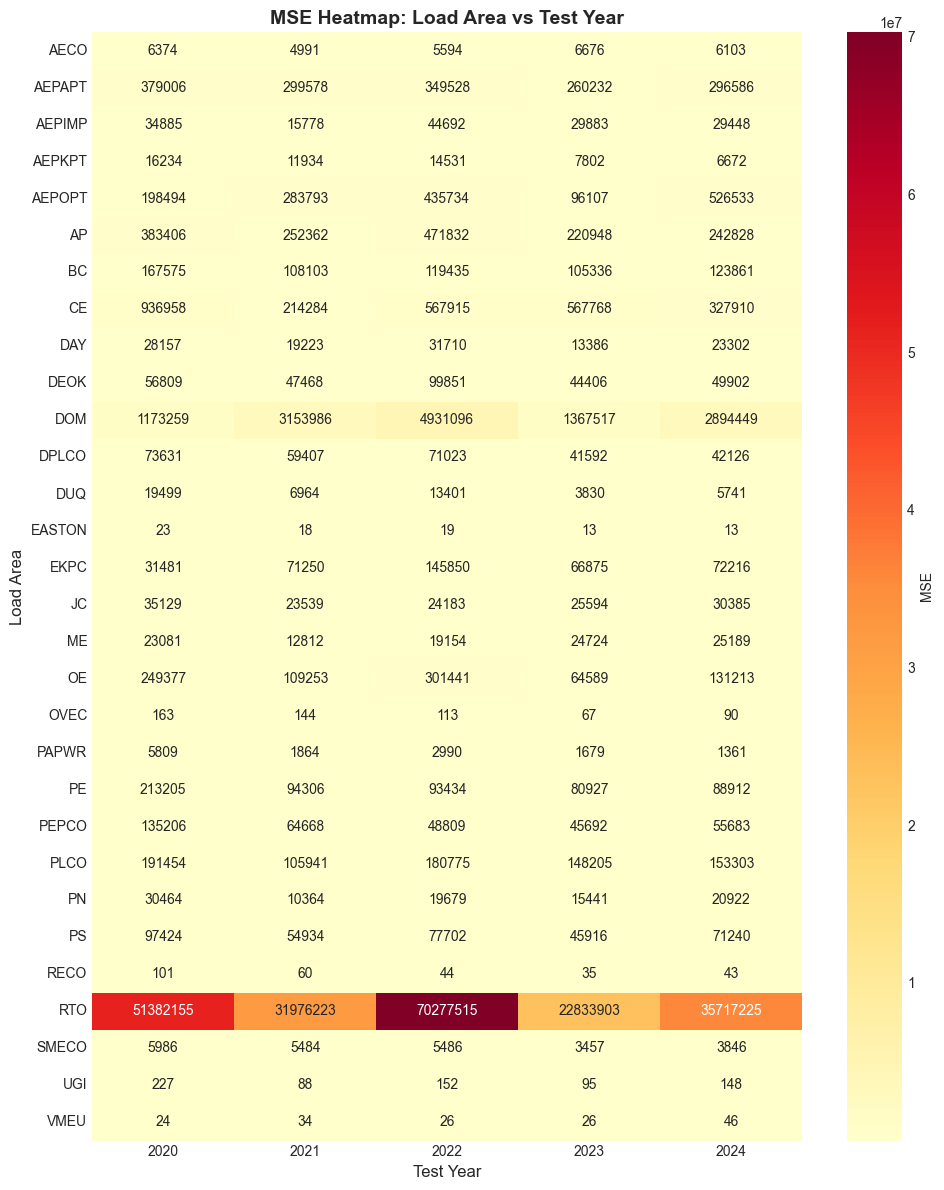

In [12]:
# Plot 3: Heatmap of MSE by area and year
pivot_mse = results_df.pivot(index='load_area', columns='test_year', values='mse')

plt.figure(figsize=(10, 12))
sns.heatmap(pivot_mse, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'MSE'})
plt.xlabel('Test Year', fontsize=12)
plt.ylabel('Load Area', fontsize=12)
plt.title('MSE Heatmap: Load Area vs Test Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

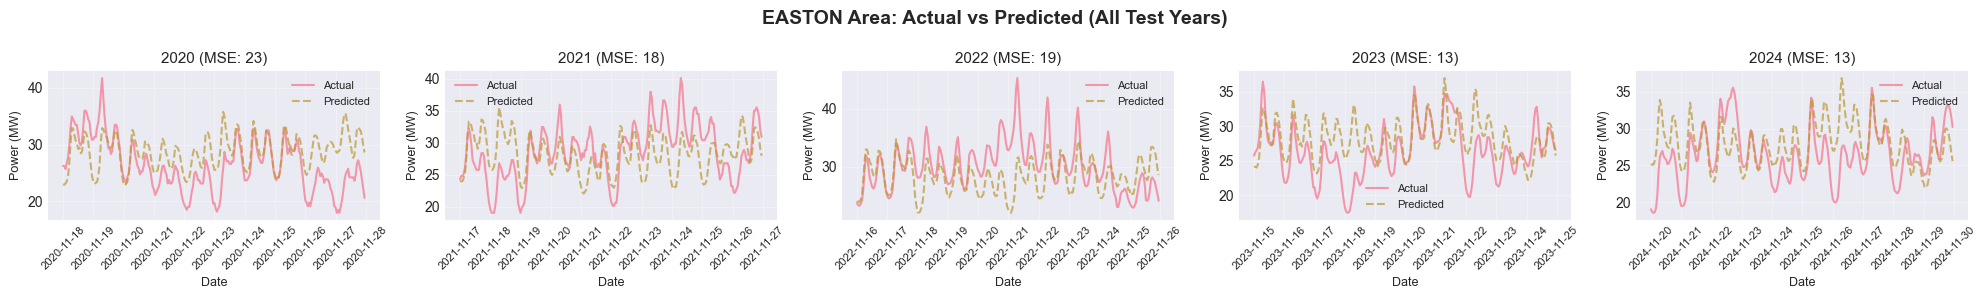

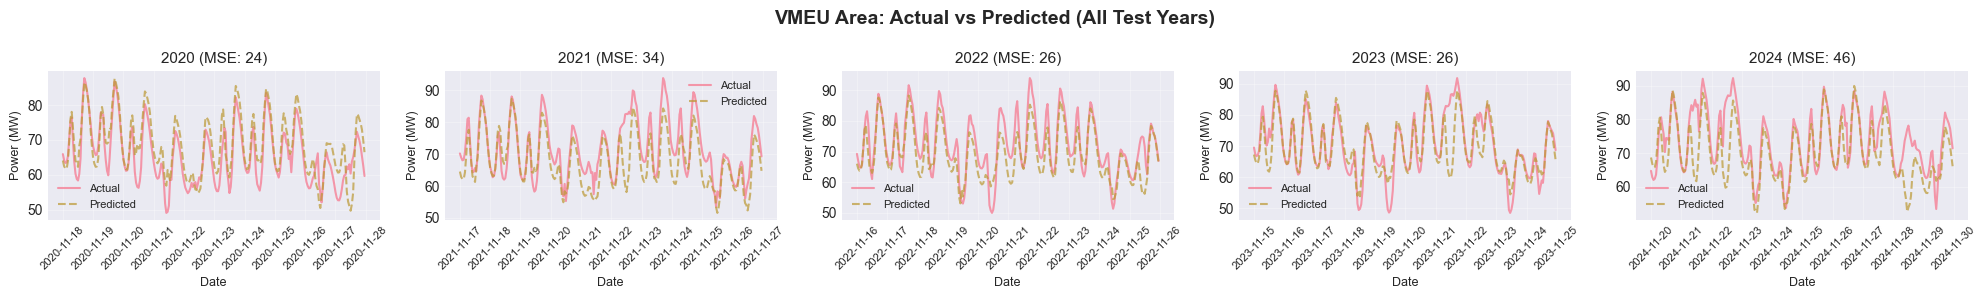

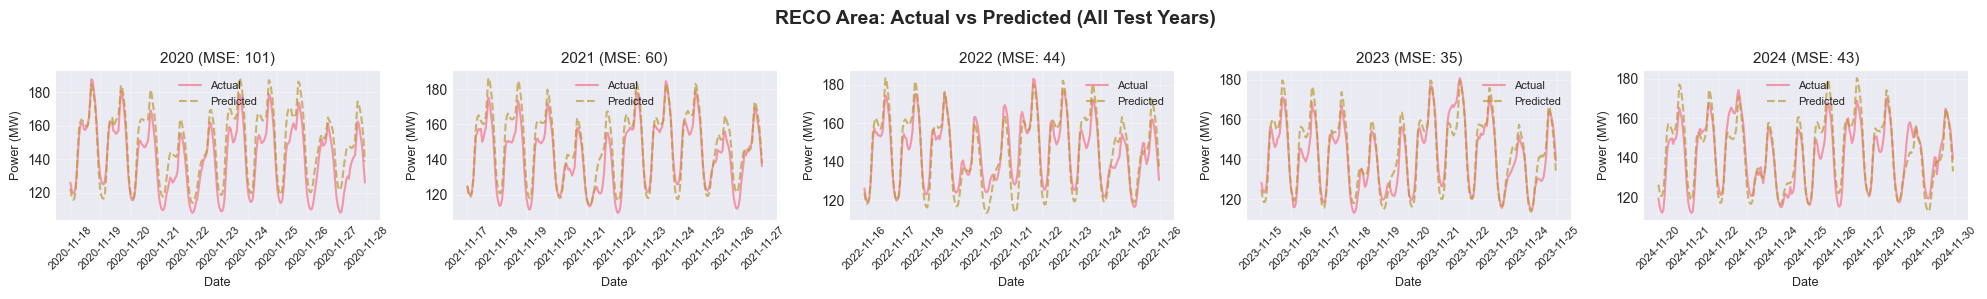

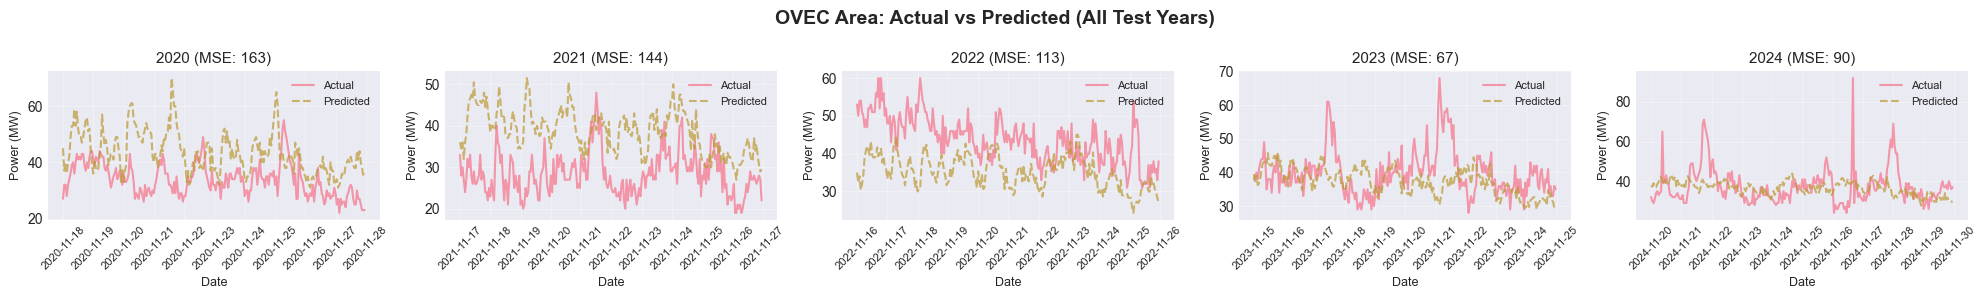

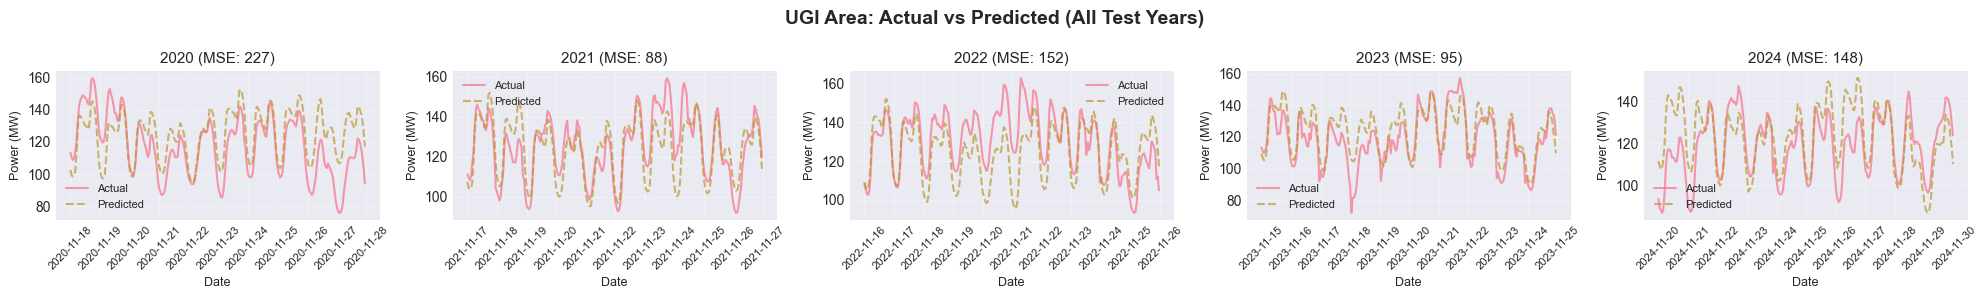

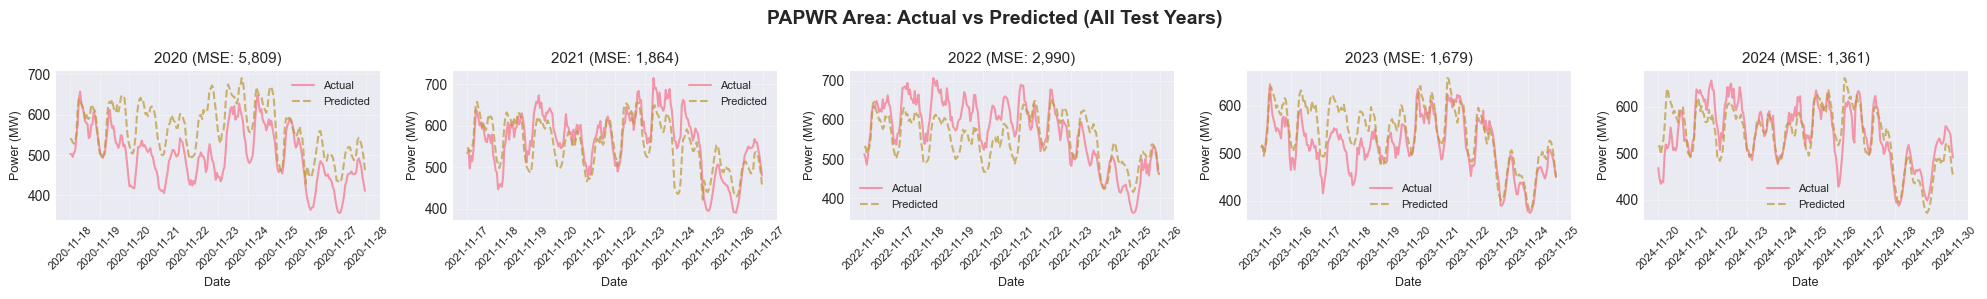

In [13]:
# Plot 4: Sample predictions for top 6 areas
top_areas = area_summary.nlargest(6, 'total_predictions')['load_area'].values

for area in top_areas:
    fig, axes = plt.subplots(1, 5, figsize=(20, 3))
    fig.suptitle(f'{area} Area: Actual vs Predicted (All Test Years)', fontsize=14, fontweight='bold')
    
    for idx, year in enumerate(sorted(all_predictions_df['test_year'].unique())):
        ax = axes[idx]
        
        data = all_predictions_df[
            (all_predictions_df['load_area'] == area) & 
            (all_predictions_df['test_year'] == year)
        ].sort_values('datetime_beginning_ept')
        
        if len(data) > 0:
            ax.plot(data['datetime_beginning_ept'], data['mw'], label='Actual', linewidth=1.5, alpha=0.7)
            ax.plot(data['datetime_beginning_ept'], data['predicted_mw'], label='Predicted', linewidth=1.5, alpha=0.7, linestyle='--')
            
            year_mse = results_df[(results_df['load_area'] == area) & (results_df['test_year'] == year)]['mse'].values
            if len(year_mse) > 0:
                ax.set_title(f'{year} (MSE: {year_mse[0]:,.0f})', fontsize=11)
            else:
                ax.set_title(f'{year}', fontsize=11)
            
            ax.set_xlabel('Date', fontsize=9)
            ax.set_ylabel('Power (MW)', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    plt.tight_layout()
    plt.show()